In [1]:
%load_ext autoreload
%autoreload 2

import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from pathlib import Path
import sys
_here = Path.cwd().resolve()
_root = next(p for p in [_here, *_here.parents] if (p / "src").is_dir())
sys.path.insert(0, str(_root / "src"))
from regression_modelling.constants import PREDICTOR_COLS, TARGET_CATEGORIES
from regression_modelling.data_wrangling.dataset import build_model_table

In [5]:
# Build the Chicago and Houston crime tables
sns.set_theme(style="whitegrid")
#start_time = time.time()
hou = build_model_table("houston", refresh=True)
chi = build_model_table("chicago",refresh=True)
kc = build_model_table("kansas_city",refresh=True)
#end_time = time.time()
#print(f"Time taken to build model tables: {end_time - start_time:.2f} seconds")
tables = {
    "houston": hou, 
    "chicago": chi,
    "kansas_city": kc}   # already built above

Houston city boundary loaded: 1 row(s)
Houston state block groups loaded: 18,626
Block groups within city: 1,629 / 18,626


/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/crime_blockgroup_mapping/boundaries.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bg['centroid'] = bg.geometry.centroid


Houston year_filter [2025-01-01, 2026-01-01): kept 240,696 of 240,696 rows (0 unparseable dates dropped)
Houston crime data: 237,011 rows with valid coords (of 240,696)
Matched to BG: 236,917 | Unmatched: 94
Mapped: 132,286 / 237,011 (55.8%)
Category counts:
crime_category
larceny     67789
vandal      20426
assault     13041
mvt         12355
burglary    11284
robbery      4973
rape         1921
murder        289
fire          208

Unmapped: 104,725 records across 38 codes
BG-level category aggregation: 2,079 BGs (1,600 within city, 479 outside)
Crime Totals:
assault_count      13032.0
murder_count         288.0
rape_count          1921.0
robbery_count       4971.0
burglary_count     11284.0
larceny_count      67775.0
mvt_count          12349.0
vandal_count       20421.0
violent_count      20212.0
property_count     91408.0
cl_total_count    111620.0
dtype: float64
Analysis set: 2,108 BGs
  Inside city:  1,629 (1,600 with data, 29 without)
  Outside city: 479 (all with crime data)
Mod

/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/crime_blockgroup_mapping/boundaries.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bg['centroid'] = bg.geometry.centroid
/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/crime_blockgroup_mapping/crime.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(df[cfg.date_col], errors='coerce')


Chicago year_filter [2025-01-01, 2026-01-01): kept 237,207 of 237,207 rows (0 unparseable dates dropped)
Chicago crime data: 235,767 rows with valid coords (of 237,207)
Matched to BG: 235,690 | Unmatched: 77
Mapped: 129,757 / 235,767 (55.0%)
Category counts:
crime_category
larceny     58322
vandal      26091
mvt         17164
assault     13640
burglary     6167
robbery      5780
rape         1792
murder        431
fire          370

Unmapped: 106,010 records across 15 codes
BG-level category aggregation: 2,256 BGs (2,164 within city, 92 outside)
Crime Totals:
assault_count      13636.0
murder_count         429.0
rape_count          1792.0
robbery_count       5775.0
burglary_count      6167.0
larceny_count      58295.0
mvt_count          17163.0
vandal_count       26081.0
violent_count      21632.0
property_count     81625.0
cl_total_count    103257.0
dtype: float64
Analysis set: 2,256 BGs
  Inside city:  2,164 (2,164 with data, 0 without)
  Outside city: 92 (all with crime data)
Model 

/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/crime_blockgroup_mapping/boundaries.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bg['centroid'] = bg.geometry.centroid


Block groups within city: 473 / 5,031
Kansas City year_filter [2025-01-01, 2026-01-01): kept 97,557 of 99,085 rows (1 unparseable dates dropped)
Kansas City dedup on ('report_no', 'ibrs'): kept 55,168 of 97,557 rows
Kansas City crime data: 53,469 rows with valid coords (of 55,168)
Matched to BG: 53,266 | Unmatched: 203
Mapped: 28,853 / 53,469 (54.0%)
Category counts:
crime_category
larceny     10115
mvt          5814
vandal       5184
assault      3519
burglary     2576
robbery      1007
rape          452
murder        117
fire           69

Unmapped: 18,657 records across 34 codes
BG-level category aggregation: 660 BGs (473 within city, 187 outside)
Crime Totals:
assault_count      3504.0
murder_count        117.0
rape_count          449.0
robbery_count      1004.0
burglary_count     2572.0
larceny_count     10091.0
mvt_count          5796.0
vandal_count       5179.0
violent_count      5074.0
property_count    18459.0
cl_total_count    23533.0
dtype: float64
Analysis set: 660 BGs
  In

In [6]:
# Check percentile values of columns
def describe_cols(df, cols):
    d = df[cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
    d["skew"] = df[cols].skew()
    d["n_missing"] = df[cols].isna().sum()
    return d.round(2)

for city, df in tables.items():
    print(f"\n{'='*70}\n{city.upper()} — predictor summary\n{'='*70}")
    display(describe_cols(df, PREDICTOR_COLS))


HOUSTON — predictor summary


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,n_missing
det_pct,1629.0,47.517885,37.418067,0.0,0.0,0.0,7.725322,45.959596,84.836601,100.0,100.0,100.0,0.08,0
in_household_pct,1629.0,98.908817,5.963791,0.0,76.718118,96.87368,99.514644,100.0,100.0,100.0,100.0,100.0,-11.79,0
moved1yr_pct,1629.0,17.046439,11.303803,0.0,1.744014,3.266941,8.749722,14.474352,23.105406,40.197655,49.932157,66.498952,1.1,0
city_centers_dist,1629.0,19.644084,8.733951,1.0,10.0,10.0,15.0,20.0,20.0,30.0,50.0,50.0,1.72,0
pop_est_5mile,1629.0,404239.399632,126370.435612,57007.0,134393.36,187750.8,317643.0,395354.0,506825.0,603121.2,634320.56,642921.0,-0.11,0
pop_ch_1mile,1629.0,-0.652543,9.559594,-59.292262,-29.615071,-18.787191,-5.881009,1.175382,5.780752,11.633369,16.637556,24.257784,-1.04,0
vacant_pct,1629.0,2.912773,3.894604,0.0,0.0,0.0,0.659522,1.606922,3.623814,9.784442,17.878282,42.026709,3.8,0
clip_liens_pct,1629.0,0.023143,0.467208,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2372,16.67,30.86,0
clip_foreclosure_pct,1629.0,0.341762,1.040098,0.0,0.0,0.0,0.0,0.0,0.44,1.218,3.1516,33.33,21.04,0
unq_convenience_stores_clips,1629.0,1.312462,1.5177,0.0,0.0,0.0,0.0,1.0,2.0,4.0,6.0,18.0,2.55,0



CHICAGO — predictor summary


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,n_missing
det_pct,2164.0,32.398311,30.414017,0.0,0.0,0.0,6.915731,22.072341,51.613182,95.304922,100.0,100.0,0.84,0
in_household_pct,2164.0,98.606317,5.331144,4.98229,80.040527,93.56469,99.381835,99.893933,100.0,100.0,100.0,100.0,-9.12,0
moved1yr_pct,2164.0,13.561184,9.186922,0.0,0.708933,2.179517,6.06239,11.72756,18.68305,32.374614,39.116976,55.360094,0.92,0
city_centers_dist,2164.0,18.767048,6.868391,1.0,5.0,10.0,15.0,20.0,20.0,30.0,30.0,30.0,0.31,0
pop_est_5mile,2164.0,875513.223198,273621.78157,208801.0,261293.53,421187.15,686500.75,867731.0,1083399.5,1325543.25,1393617.73,1437536.0,-0.09,0
pop_ch_1mile,2164.0,3.732812,6.070185,-18.617454,-15.057998,-8.449311,0.819161,4.634319,8.058668,11.451671,14.741413,18.136991,-0.96,0
vacant_pct,2164.0,3.663941,3.718547,0.0,0.085385,0.407457,1.240438,2.366228,4.722769,11.944251,17.462815,25.816024,2.03,0
clip_liens_pct,2164.0,0.020522,0.136648,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5411,4.55,19.09,0
clip_foreclosure_pct,2164.0,0.940236,1.408523,0.0,0.0,0.0,0.0,0.35,1.3625,3.77,5.8611,17.65,2.66,0
unq_convenience_stores_clips,2164.0,0.624307,1.232471,0.0,0.0,0.0,0.0,0.0,1.0,2.0,3.37,38.0,14.24,0



KANSAS_CITY — predictor summary


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,n_missing
det_pct,473.0,64.063658,34.216914,0.0,0.0,0.0,37.236084,75.165563,95.132743,100.0,100.0,100.0,-0.63,0
in_household_pct,473.0,98.155287,4.493626,60.373832,76.599874,92.689851,98.036498,99.701654,100.0,100.0,100.0,100.0,-4.92,0
moved1yr_pct,473.0,16.525464,9.491717,0.0,1.768539,3.523422,10.280023,14.129715,21.717791,36.027055,44.03346,51.156973,0.99,0
city_centers_dist,473.0,14.581582,5.416037,1.0,3.88,5.0,10.0,15.0,15.0,21.831216,30.0,50.0,1.17,0
pop_est_5mile,473.0,193854.323467,55328.880184,22104.0,76627.44,99803.2,150436.0,192429.0,241726.0,276043.6,284711.84,286451.0,-0.25,0
pop_ch_1mile,473.0,1.17467,11.348387,-48.076923,-32.588232,-22.554353,-4.4453,3.028884,9.338372,15.644163,18.645634,36.395582,-1.1,0
vacant_pct,473.0,5.073127,5.21151,0.0,0.0,0.0,1.345291,3.278689,7.415036,15.441734,22.334996,31.603774,1.58,0
clip_liens_pct,473.0,0.0174,0.090133,0.0,0.0,0.0,0.0,0.0,0.0,0.072,0.41,1.14,7.23,0
clip_foreclosure_pct,473.0,0.584524,0.757615,0.0,0.0,0.0,0.0,0.28,0.93,2.148,2.9916,4.5,1.67,0
unq_convenience_stores_clips,473.0,0.623679,0.933163,0.0,0.0,0.0,0.0,0.0,1.0,2.0,4.0,6.0,2.06,0


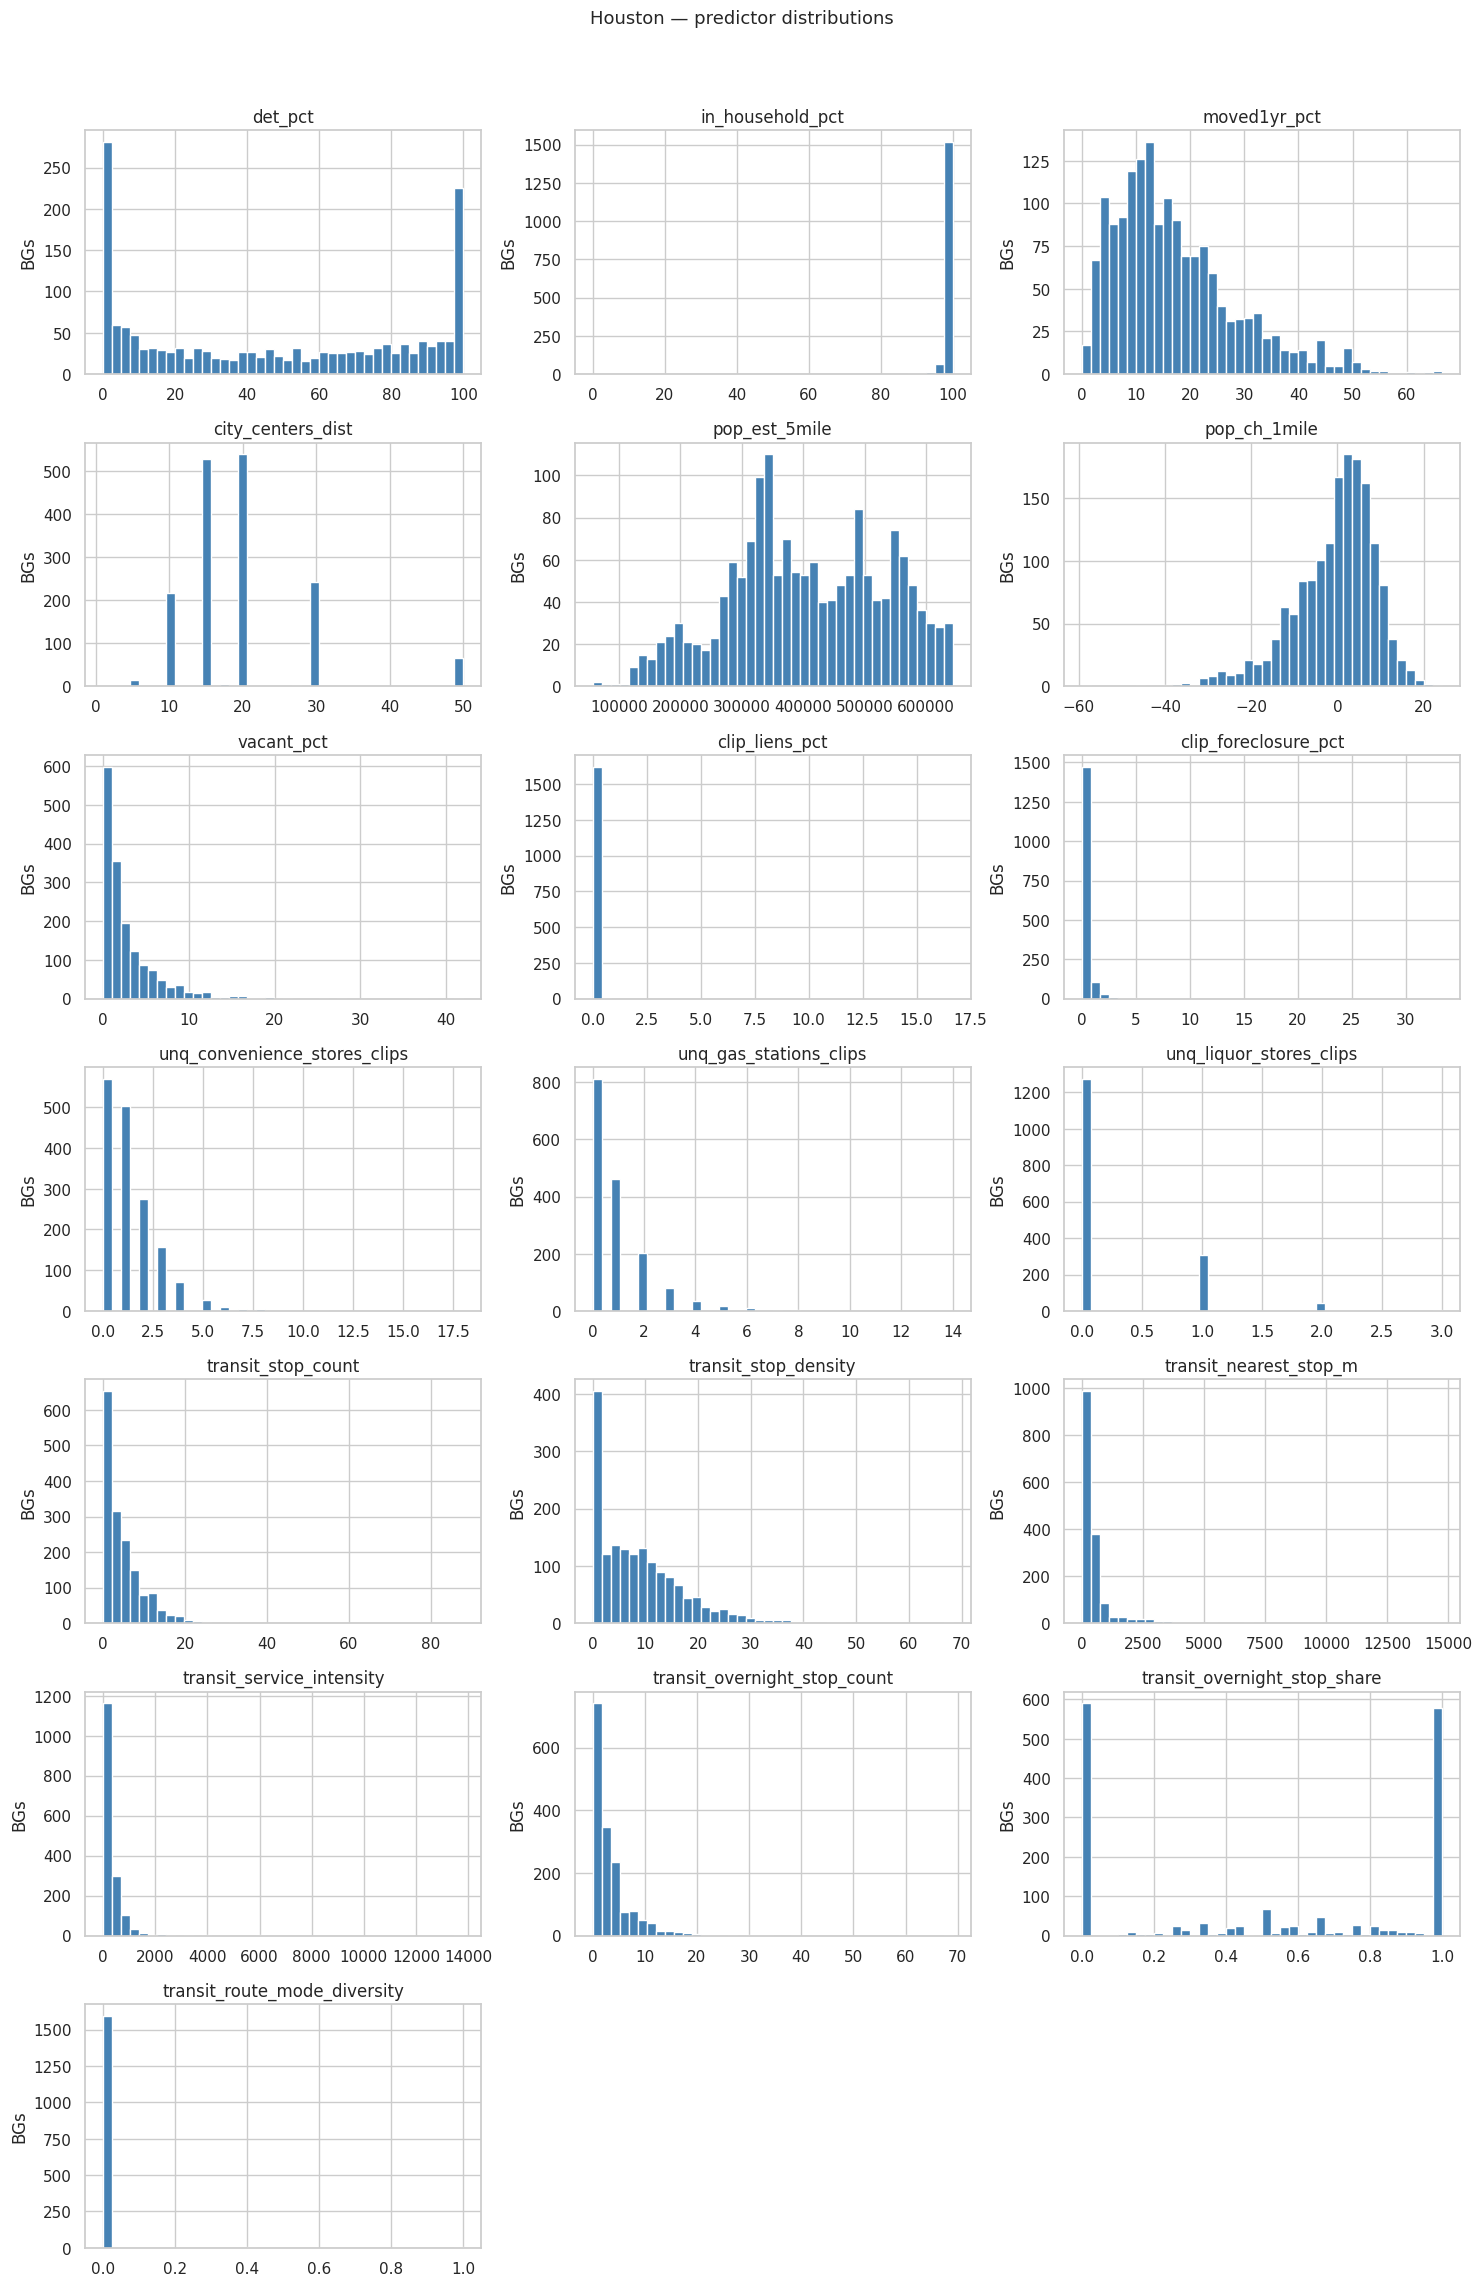

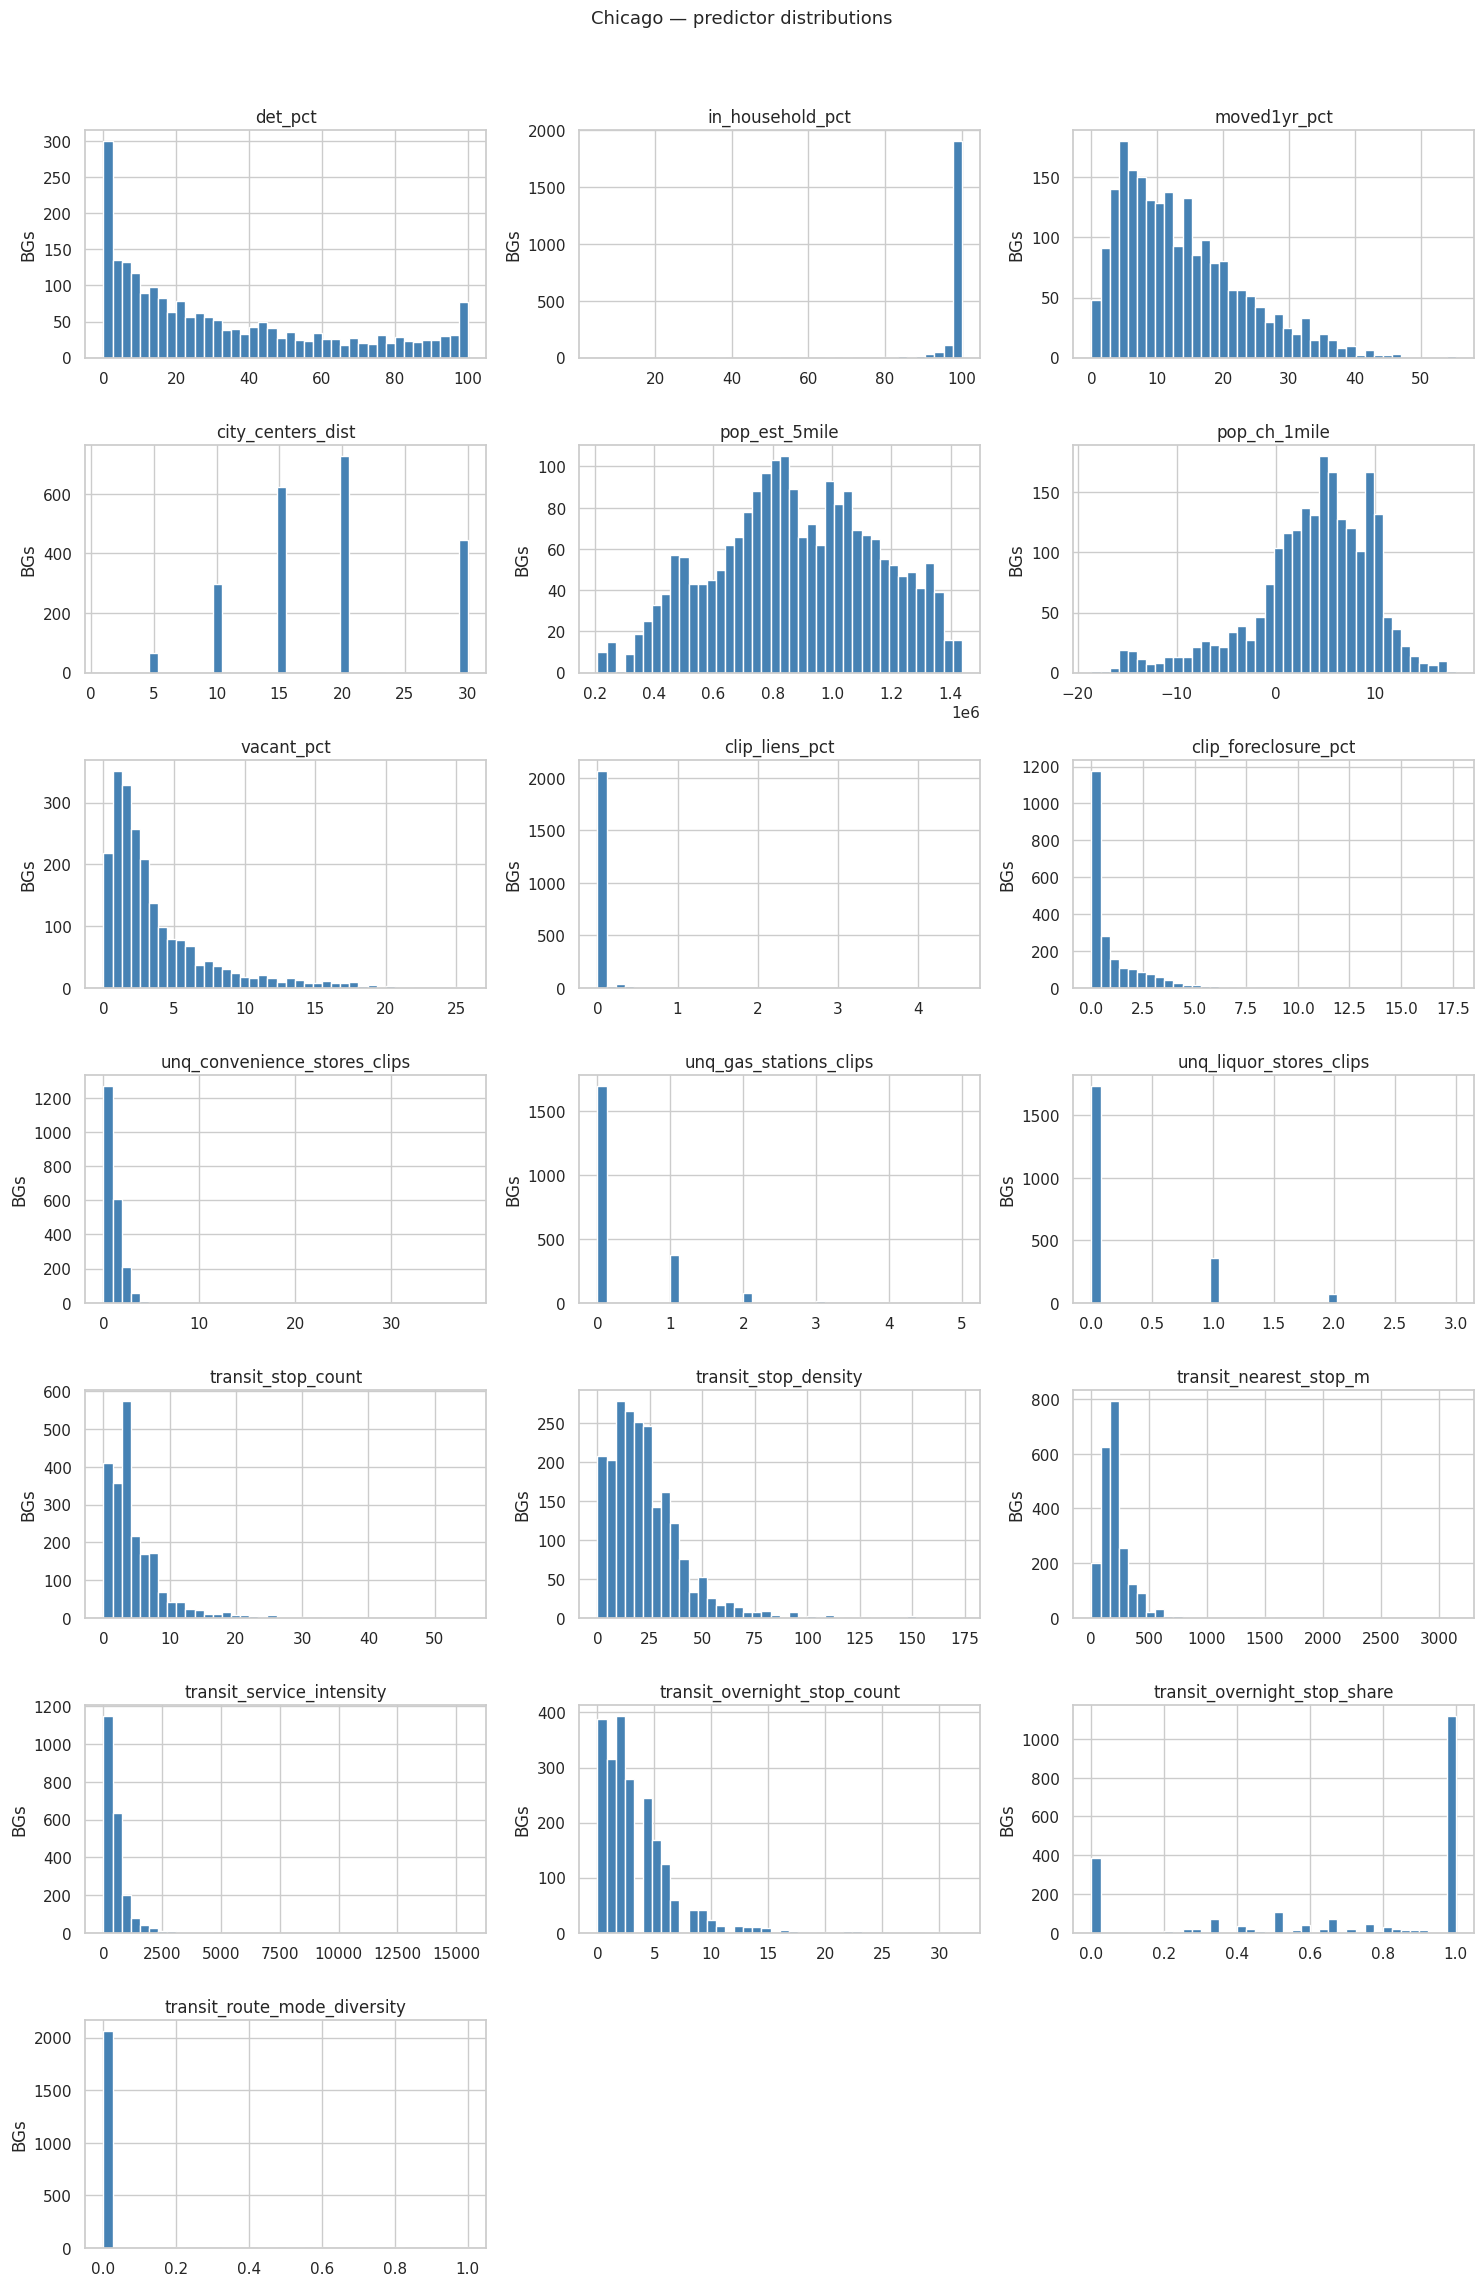

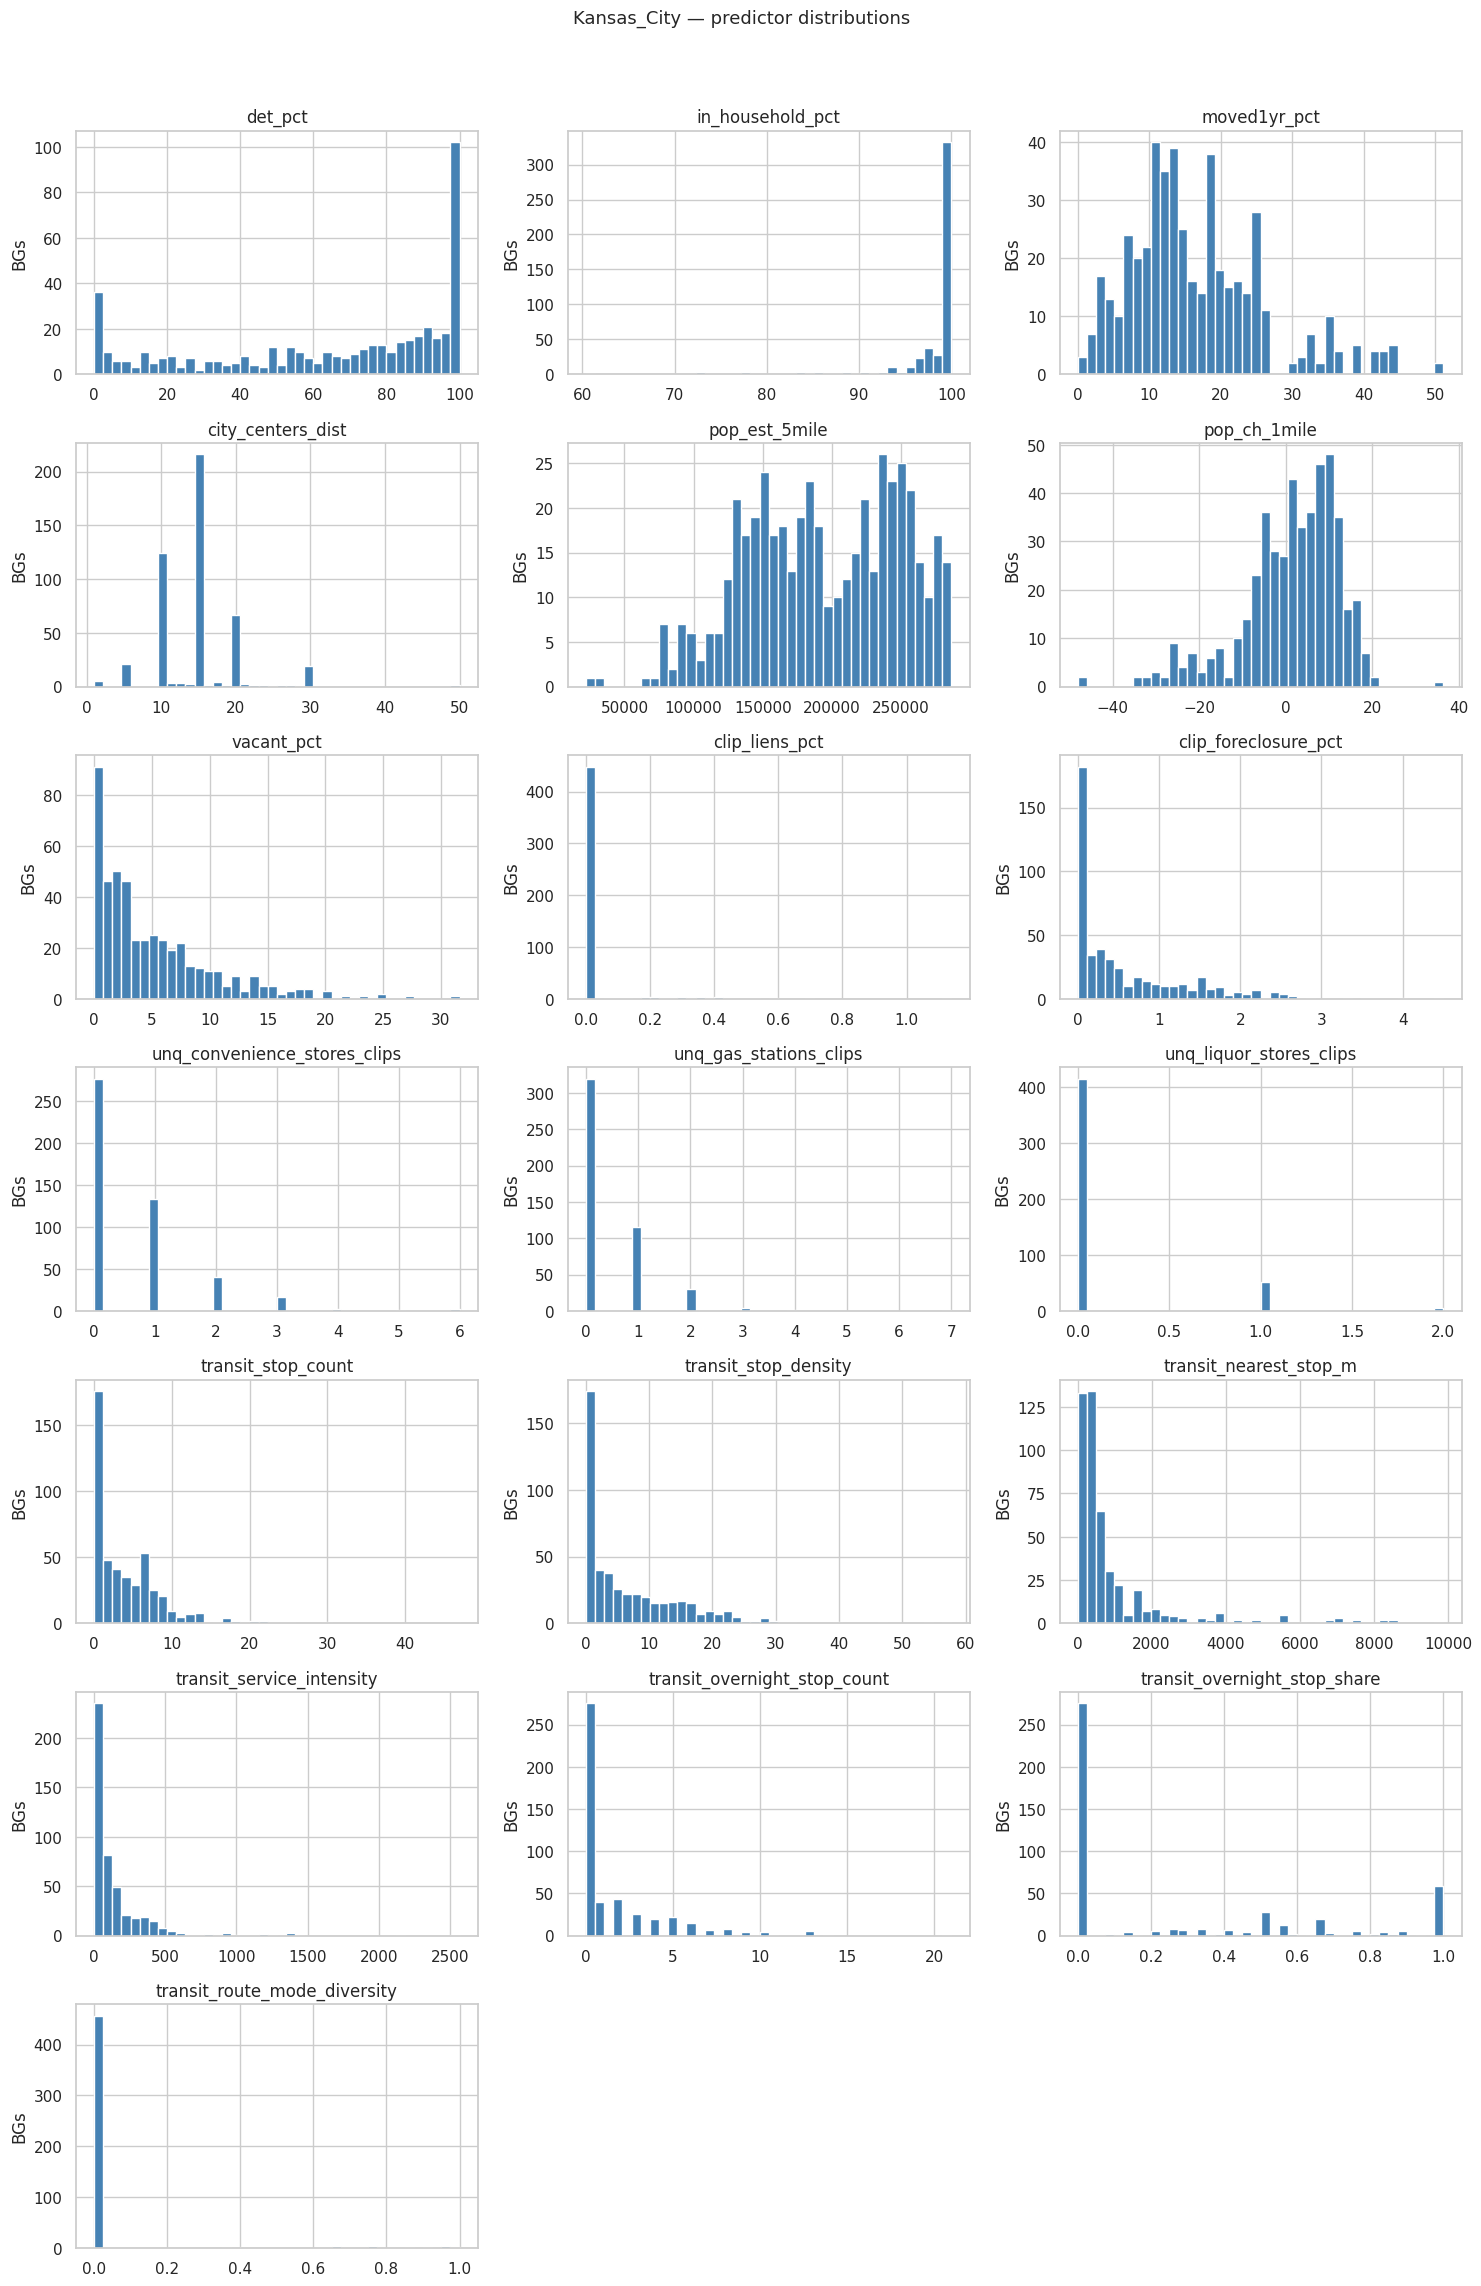

In [7]:
# Predictor distributions
def plot_grid(df, cols, title, bins=40, color="steelblue"):
    ncol = 3
    nrow = int(np.ceil(len(cols) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 3.2 * nrow))
    for ax, c in zip(axes.ravel(), cols):
        ax.hist(df[c].dropna(), bins=bins, color=color, edgecolor="white")
        ax.set_title(c); ax.set_ylabel("BGs")
    for ax in axes.ravel()[len(cols):]:
        ax.set_visible(False)
    fig.suptitle(title, fontsize=13, y=1.02); fig.tight_layout(); plt.show()

for city, df in tables.items():
    plot_grid(df, PREDICTOR_COLS, f"{city.title()} — predictor distributions")

In [8]:
# Target summary
# pct_zero is the key column: a target with very high zero-fraction is a poor
# candidate for OLS on log-count and may need pooling or a count model.
def target_summary(df):
    rows = []
    for c in TARGET_CATEGORIES:
        cnt = df[f"{c}_count"]
        rows.append({
            "target": c, "total": int(cnt.sum()), "mean": round(cnt.mean(), 2),
            "p50": cnt.median(), "p95": cnt.quantile(.95), "max": cnt.max(),
            "pct_zero": round((cnt == 0).mean() * 100, 1), "skew": round(cnt.skew(), 2),
        })
    return pd.DataFrame(rows)

for city, df in tables.items():
    print(f"\n{city.upper()} — target (count) summary")
    display(target_summary(df))


HOUSTON — target (count) summary


,target,total,mean,p50,p95,max,pct_zero,skew
0,cl_total,107678,66.10,42.0,205.0,1014.0,2.7,4.13
1,violent,19555,12.00,8.0,36.0,127.0,8.0,2.56
2,property,88123,54.10,33.0,177.0,967.0,3.1,4.52
3,assault,12614,7.74,5.0,25.0,86.0,11.8,2.50
4,murder,278,0.17,0.0,1.0,4.0,86.1,3.06
5,rape,1841,1.13,1.0,4.0,39.0,47.0,7.18
6,robbery,4822,2.96,1.0,11.0,37.0,30.9,2.48
7,burglary,10946,6.72,5.0,21.0,48.0,11.4,1.97
8,larceny,65385,40.14,20.0,144.4,912.0,4.1,5.06
9,mvt,11792,7.24,5.0,22.0,163.0,10.3,5.57



CHICAGO — target (count) summary


,target,total,mean,p50,p95,max,pct_zero,skew
0,cl_total,102722,47.47,32.0,124.0,1581.0,0.2,9.76
1,violent,21553,9.96,6.0,33.0,186.0,7.3,3.46
2,property,81169,37.51,25.0,99.0,1395.0,0.2,10.29
3,assault,13591,6.28,4.0,21.0,90.0,13.3,2.65
4,murder,429,0.20,0.0,1.0,5.0,85.0,3.66
5,rape,1786,0.83,0.0,3.0,55.0,57.4,12.88
6,robbery,5747,2.66,1.0,9.0,87.0,29.7,6.41
7,burglary,6130,2.83,2.0,8.0,25.0,18.4,2.22
8,larceny,57954,26.78,15.0,78.0,1299.0,0.5,11.32
9,mvt,17085,7.90,6.0,21.0,123.0,4.3,3.79



KANSAS_CITY — target (count) summary


,target,total,mean,p50,p95,max,pct_zero,skew
0,cl_total,22795,48.19,37.0,127.2,374.0,0.4,3.07
1,violent,4998,10.57,7.0,33.4,73.0,8.7,1.78
2,property,17797,37.63,27.0,103.0,329.0,0.4,3.62
3,assault,3452,7.30,5.0,23.4,54.0,12.5,1.93
4,murder,117,0.25,0.0,1.0,4.0,79.5,2.51
5,rape,443,0.94,0.0,3.0,13.0,51.6,3.24
6,robbery,986,2.08,1.0,8.0,16.0,38.9,2.04
7,burglary,2529,5.35,4.0,15.0,48.0,12.5,2.78
8,larceny,9588,20.27,13.0,57.4,234.0,0.8,4.29
9,mvt,5680,12.01,8.0,34.4,151.0,5.1,4.42


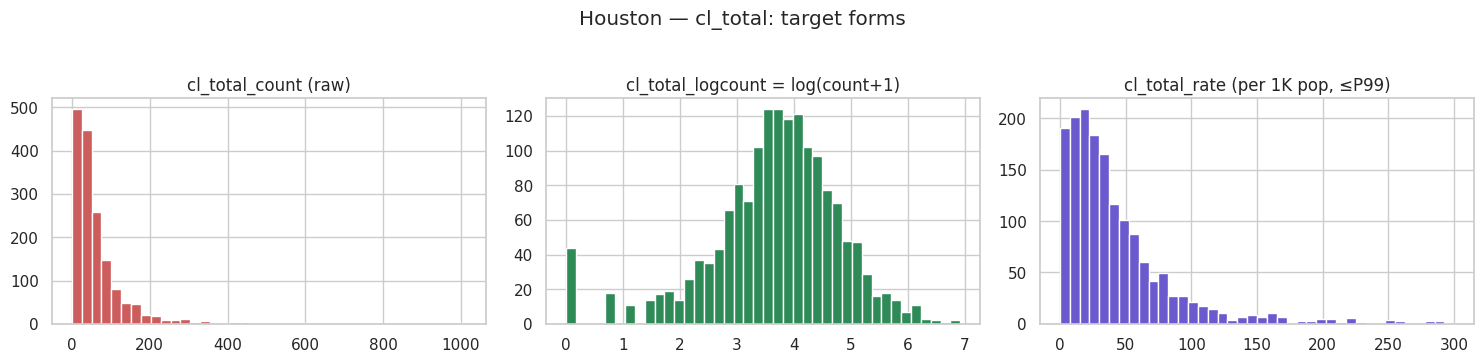

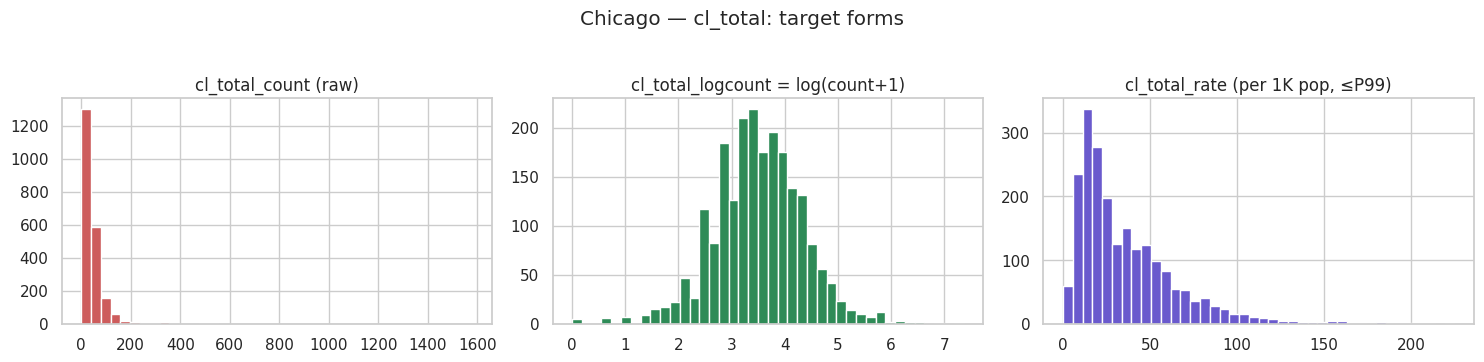

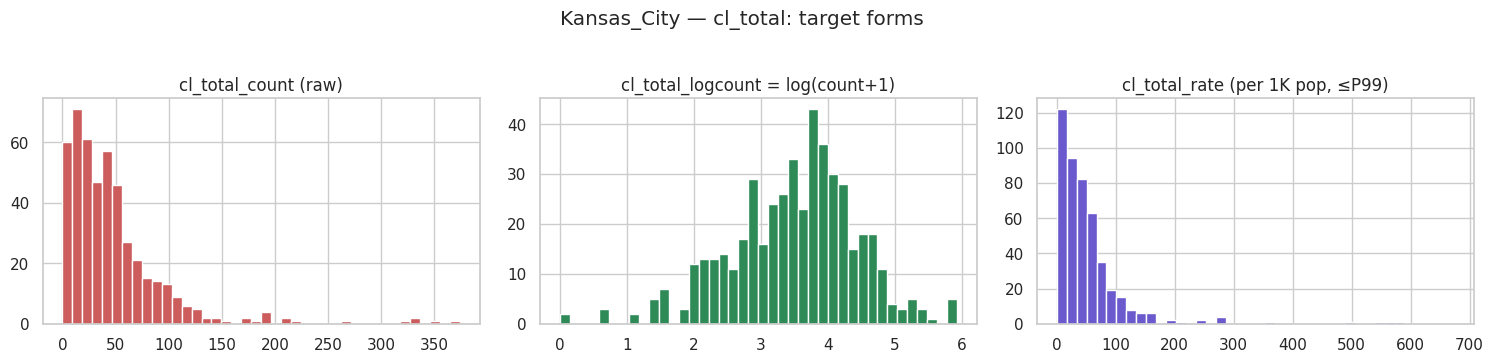

In [9]:
# Confirms log(count+1) tames the skew that raw counts show — justifying the OLS target.
def plot_target_forms(df, cat, city, rate_clip_pct=99):
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
    axes[0].hist(df[f"{cat}_count"], bins=40, color="indianred", edgecolor="white")
    axes[0].set_title(f"{cat}_count (raw)")
    axes[1].hist(df[f"{cat}_logcount"], bins=40, color="seagreen", edgecolor="white")
    axes[1].set_title(f"{cat}_logcount = log(count+1)")

    rate = df[f"{cat}_rate"].dropna()
    rate_range = (0, rate.quantile(rate_clip_pct / 100)) if rate_clip_pct else None
    axes[2].hist(rate, bins=40, range=rate_range, color="slateblue", edgecolor="white")
    axes[2].set_title(f"{cat}_rate (per 1K pop, ≤P{rate_clip_pct})")

    fig.suptitle(f"{city} — {cat}: target forms", y=1.03); fig.tight_layout(); plt.show()

for city, df in tables.items():
    plot_target_forms(df, "cl_total", city.title())

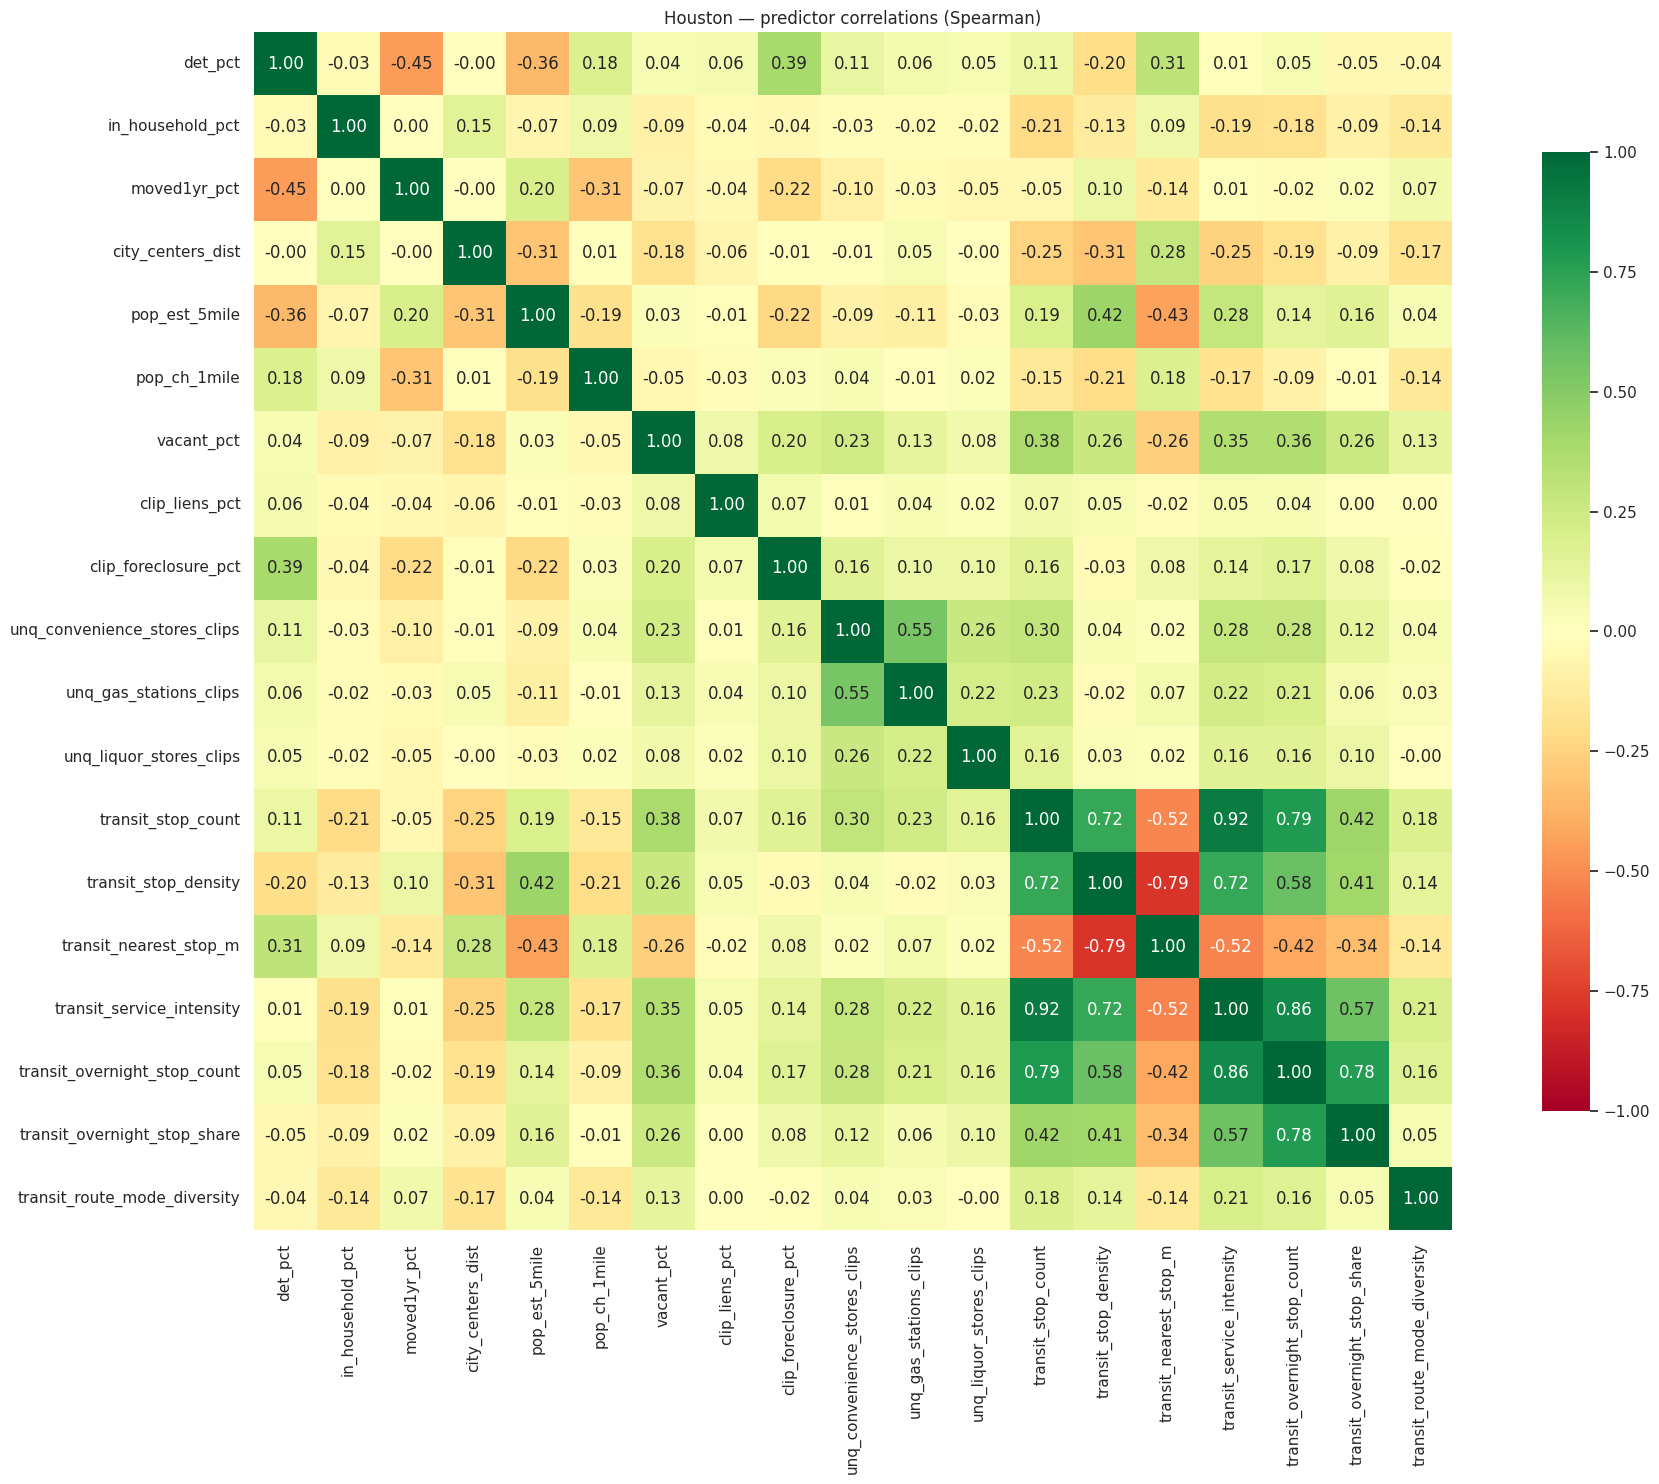

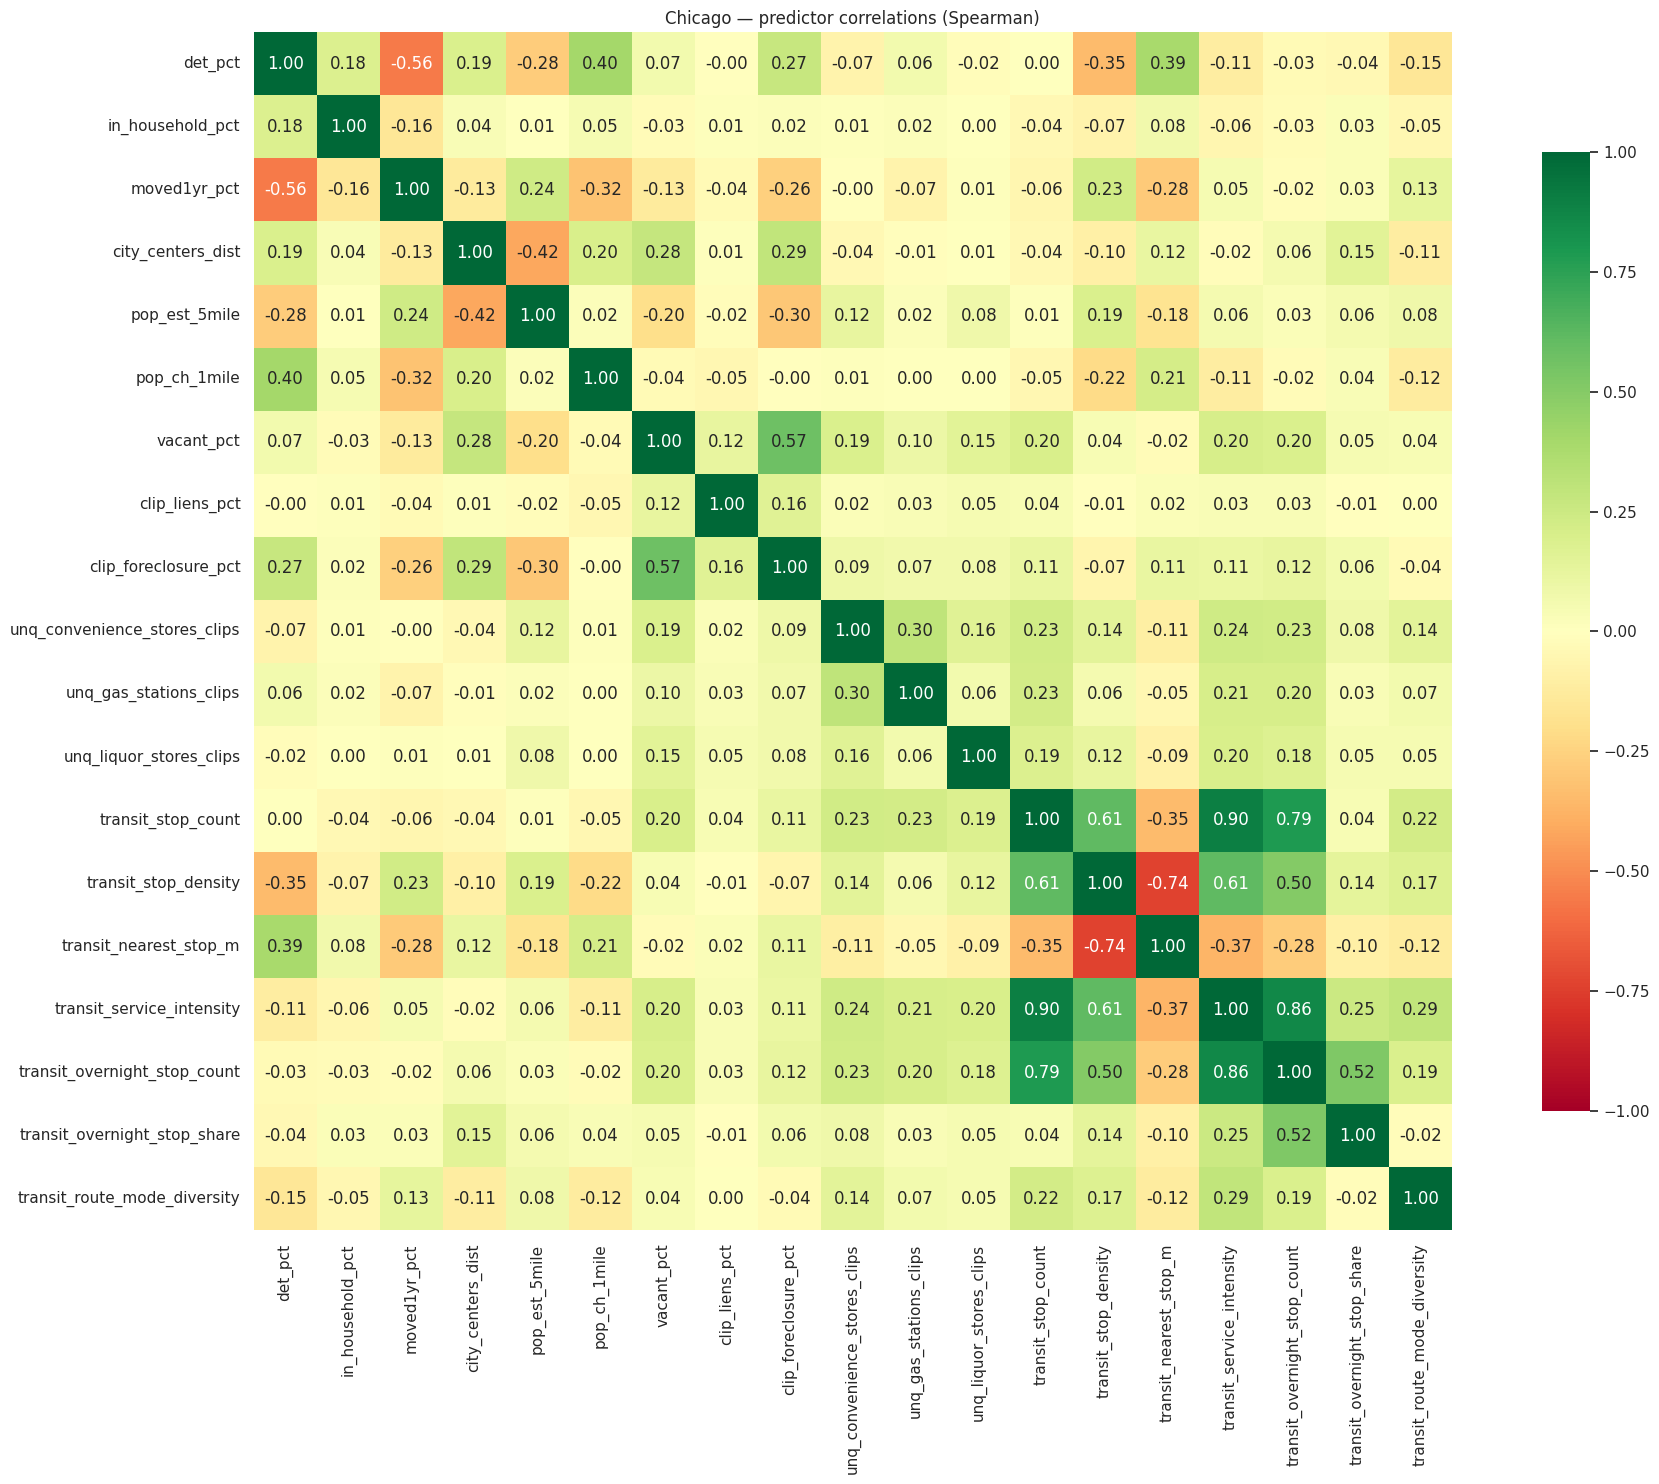

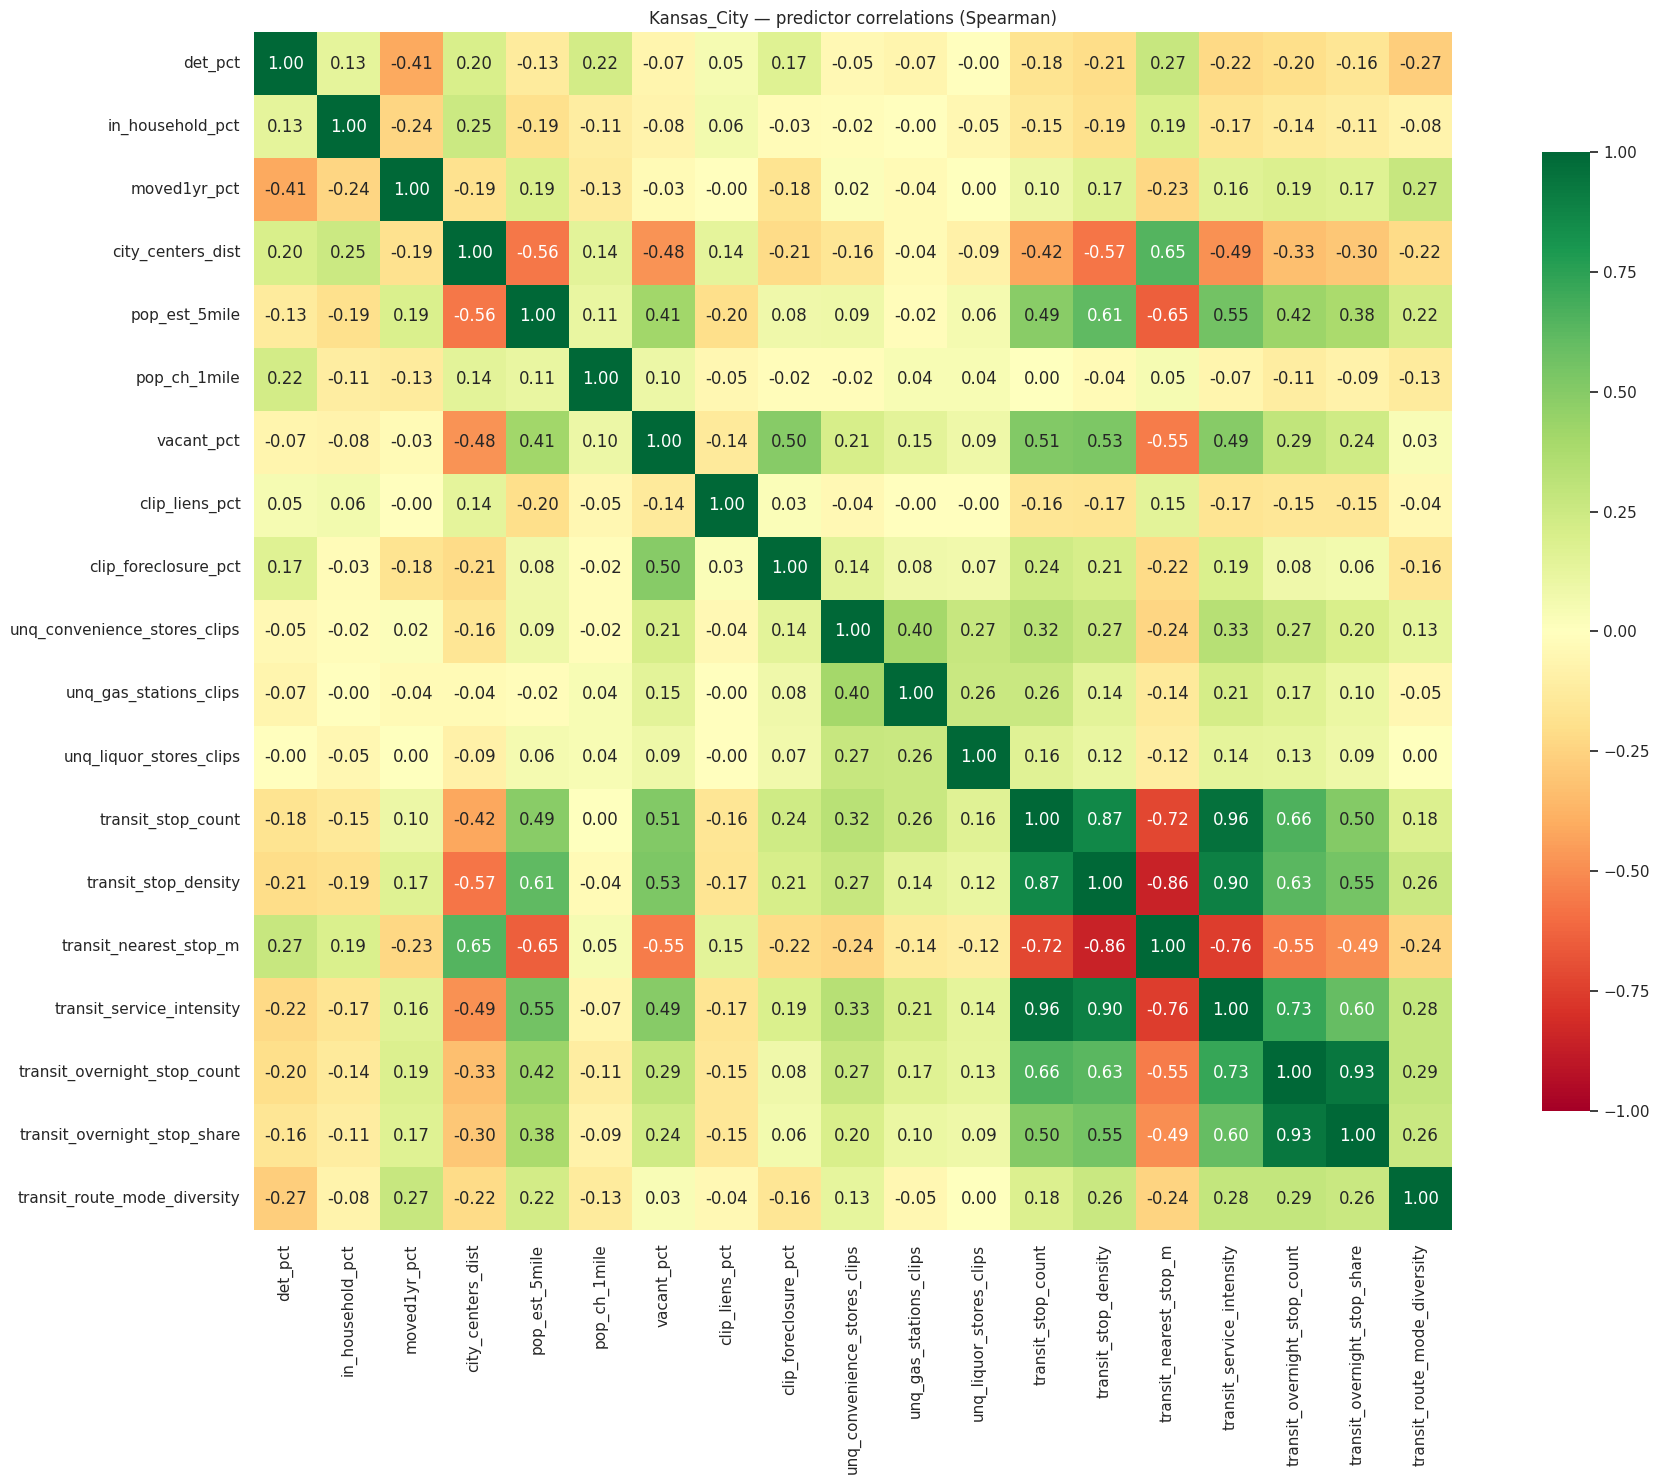

In [11]:
# Correlation heatmap
def corr_heatmap(df, cols, title):
    corr = df[cols].corr(method="spearman")
    fig, ax = plt.subplots(figsize=(20, 15))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
                vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8}, ax=ax)
    ax.set_title(title); plt.tight_layout(); plt.show()

for city, df in tables.items():
    corr_heatmap(df, PREDICTOR_COLS, f"{city.title()} — predictor correlations (Spearman)")

In [12]:
df[PREDICTOR_COLS].dtypes

det_pct                         float64
in_household_pct                float64
moved1yr_pct                    float64
city_centers_dist               float64
pop_est_5mile                   float64
pop_ch_1mile                    float64
vacant_pct                      float64
clip_liens_pct                  float64
clip_foreclosure_pct            float64
unq_convenience_stores_clips    float64
unq_gas_stations_clips          float64
unq_liquor_stores_clips         float64
transit_stop_count                Int64
transit_stop_density            float64
transit_nearest_stop_m          float64
transit_service_intensity       float64
transit_overnight_stop_count    float64
transit_overnight_stop_share    float64
transit_route_mode_diversity    float64
dtype: object

In [ ]:
# VIF calculation

def vif_table(df, cols):
    Xnum = df[cols].apply(pd.to_numeric, errors="coerce").astype("float64")
    X = add_constant(df[cols].fillna(df[cols].median()))
    vif = pd.DataFrame({
        "feature": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    })
    return vif[vif["feature"] != "const"].sort_values("VIF", ascending=False).round(2)

for city, df in tables.items():
    print(f"\n{city.upper()} — VIF")
    display(vif_table(df, PREDICTOR_COLS))

In [14]:
# Spearman of each predictor against each target (log-count). Directional preview
# of which predictors carry signal before fitting.
def predictor_target_corr(df, targets, suffix):
    tcols = [f"{t}_{suffix}" for t in targets]
    corr = df[PREDICTOR_COLS + tcols].corr(method="spearman").loc[PREDICTOR_COLS, tcols]
    corr.columns = targets
    return corr.round(2)

for city, df in tables.items():
    print(f"\n{city.upper()} — predictor vs target (Spearman, log-count)")
    display(predictor_target_corr(df, TARGET_CATEGORIES, "logcount"))


HOUSTON — predictor vs target (Spearman, log-count)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
det_pct,-0.16,-0.09,-0.17,-0.07,-0.02,-0.08,-0.09,-0.04,-0.17,-0.18
in_household_pct,-0.10,-0.11,-0.09,-0.11,-0.09,-0.09,-0.10,-0.09,-0.09,-0.04
moved1yr_pct,0.14,-0.05,0.18,-0.06,-0.01,0.02,-0.03,0.04,0.19,0.13
city_centers_dist,-0.18,-0.14,-0.18,-0.13,-0.07,-0.08,-0.13,-0.14,-0.18,-0.13
pop_est_5mile,0.14,0.04,0.16,-0.01,0.02,0.01,0.12,0.11,0.17,0.08
pop_ch_1mile,-0.15,0.03,-0.17,0.06,-0.02,-0.07,0.01,-0.07,-0.19,-0.08
vacant_pct,0.27,0.35,0.23,0.35,0.15,0.22,0.27,0.31,0.21,0.18
clip_liens_pct,0.06,0.04,0.05,0.05,0.06,0.01,0.03,0.06,0.05,0.03
clip_foreclosure_pct,0.10,0.18,0.06,0.19,0.11,0.09,0.10,0.17,0.05,0.04
unq_convenience_stores_clips,0.36,0.34,0.34,0.31,0.16,0.22,0.32,0.35,0.33,0.26



CHICAGO — predictor vs target (Spearman, log-count)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
det_pct,-0.31,-0.20,-0.32,-0.14,-0.07,-0.21,-0.20,-0.13,-0.38,-0.10
in_household_pct,-0.11,-0.09,-0.11,-0.08,-0.06,-0.10,-0.07,-0.06,-0.12,-0.05
moved1yr_pct,0.20,0.00,0.25,-0.06,-0.04,0.09,0.09,0.10,0.31,0.02
city_centers_dist,0.01,0.10,-0.00,0.14,-0.01,0.00,0.02,0.07,-0.05,0.09
pop_est_5mile,-0.05,-0.09,-0.04,-0.14,-0.05,-0.01,0.01,-0.05,0.04,-0.19
pop_ch_1mile,-0.29,-0.22,-0.28,-0.18,-0.09,-0.16,-0.22,-0.17,-0.28,-0.19
vacant_pct,0.39,0.52,0.30,0.54,0.27,0.24,0.36,0.26,0.21,0.41
clip_liens_pct,0.12,0.14,0.10,0.14,0.09,0.04,0.13,0.09,0.08,0.13
clip_foreclosure_pct,0.27,0.46,0.18,0.50,0.28,0.17,0.32,0.22,0.07,0.38
unq_convenience_stores_clips,0.27,0.26,0.25,0.24,0.11,0.13,0.25,0.22,0.24,0.18



KANSAS_CITY — predictor vs target (Spearman, log-count)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
det_pct,-0.38,-0.16,-0.42,-0.13,-0.05,-0.19,-0.16,-0.20,-0.39,-0.42
in_household_pct,-0.15,-0.13,-0.16,-0.10,-0.02,-0.09,-0.18,-0.11,-0.13,-0.18
moved1yr_pct,0.25,0.11,0.28,0.09,0.01,0.06,0.14,0.14,0.26,0.28
city_centers_dist,-0.44,-0.44,-0.41,-0.39,-0.24,-0.26,-0.46,-0.35,-0.33,-0.52
pop_est_5mile,0.37,0.30,0.36,0.28,0.12,0.09,0.36,0.34,0.31,0.41
pop_ch_1mile,-0.14,-0.08,-0.13,-0.07,-0.10,-0.14,-0.06,-0.04,-0.14,-0.12
vacant_pct,0.50,0.61,0.43,0.60,0.30,0.25,0.51,0.44,0.33,0.50
clip_liens_pct,-0.13,-0.11,-0.13,-0.11,-0.03,-0.04,-0.13,-0.11,-0.09,-0.16
clip_foreclosure_pct,0.27,0.48,0.18,0.51,0.23,0.20,0.30,0.27,0.11,0.19
unq_convenience_stores_clips,0.34,0.33,0.32,0.28,0.13,0.21,0.34,0.30,0.32,0.24


In [ ]:
# Correlations with rate
suffix="rate"
for city, df in tables.items():
    print(f"\n{city.upper()} — predictor vs target (Spearman, {suffix})")
    display(predictor_target_corr(df, TARGET_CATEGORIES, f"{suffix}"))